Summary Statistics:
 count    365.000000
mean     108.180518
std        6.738268
min       92.864443
25%      102.723659
50%      108.288266
75%      113.812917
max      120.585036
Name: Price, dtype: float64

Volatility: 0.009193780592563582


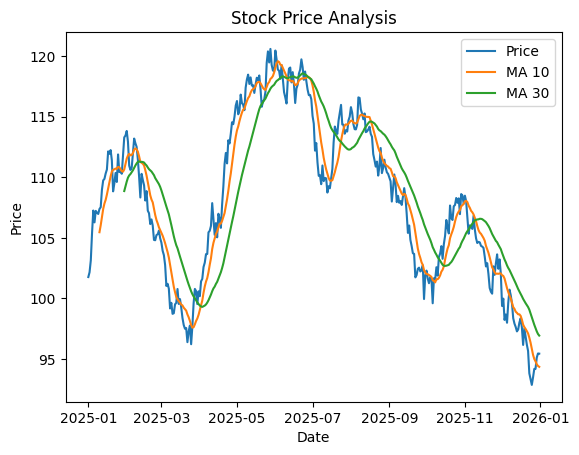

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. SIMULATION (Generate Data)

dates = pd.date_range('2025-01-01', periods=365)

np.random.seed(0)
price = 100
prices = []

for _ in range(365):
    change = np.random.normal(0, 1)   # daily fluctuation
    price += change
    prices.append(price)

df = pd.DataFrame({'Date': dates, 'Price': prices})
df.set_index('Date', inplace=True)


# 2. ANALYSIS

# Basic statistics
print("Summary Statistics:\n", df['Price'].describe())

# Daily returns
df['Return'] = df['Price'].pct_change()

# Volatility (risk)
volatility = df['Return'].std()
print("\nVolatility:", volatility)

# Moving averages
df['MA_10'] = df['Price'].rolling(10).mean()
df['MA_30'] = df['Price'].rolling(30).mean()

# 3. VISUALIZATION

plt.figure()

# Price + Moving averages
plt.plot(df['Price'], label='Price')
plt.plot(df['MA_10'], label='MA 10')
plt.plot(df['MA_30'], label='MA 30')

plt.title('Stock Price Analysis')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()